<a href="https://colab.research.google.com/github/JuniorProject21/DrugDiscovery/blob/main/DeepCoy_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit tf_keras docopt
from google.colab import drive
import os
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 29.7 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=0d58d350295b3378c136f22762132037f4d39d53a62bd8a0b9bdad3a55f14a77
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import sys
import json
import os

# Add your drive path to sys.path
drive_path = '/content/drive/MyDrive/'
sys.path.append(drive_path)

# Load and clean dataset
df = pd.read_csv("/content/drive/MyDrive/dataset_clean.csv")
newDataset = df[df['activity'] == 0][['Ligand SMILES']].reset_index(drop=True)

# Filter invalid SMILES
valid_mask = [Chem.MolFromSmiles(s) is not None for s in newDataset['Ligand SMILES']]
newDataset = newDataset[valid_mask].reset_index(drop=True)

# Preprocess into JSON for DeepCoy
import prepare_data
train_dir = '/content/drive/MyDrive/deepcoy_data/train/'
valid_dir = '/content/drive/MyDrive/deepcoy_data/valid/'
os.makedirs(train_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)

raw_data = [{'smiles_1': str(s), 'smiles_2': str(s)} for s in newDataset['Ligand SMILES']]
prepare_data.preprocess(raw_data, dataset='zinc', name='train', save_dir=train_dir)
prepare_data.preprocess(raw_data[:200], dataset='zinc', name='valid', save_dir=valid_dir)

[13:02:35] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 21
[13:02:35] Explicit valence for atom # 5 N, 4, is greater than permitted


Parsing smiles as graphs.
unrecognized atom type P5(0)
unrecognized atom type P5(0)
unrecognized atom type P5(0)
unrecognized atom type P5(0)
unrecognized atom type S3(1)
unrecognized atom type S3(1)
unrecognized atom type P5(0)
unrecognized atom type P5(0)
Processed: 1252 / 1252
Failed 4 molecules
Saving data.
Length raw data: 	1252
Length processed data: 	1248
Parsing smiles as graphs.
Processed: 200 / 200
Saving data.
Length raw data: 	200
Length processed data: 	200


In [ ]:
import types, importlib
import tensorflow.compat.v1 as tf
import tf_keras

# 1. TF1 Compatibility Shim
tf.disable_eager_execution()
class LegacyDropoutWrapper(tf_keras.layers.Layer):
    def __init__(self, cell, input_keep_prob=1.0, **kwargs):
        super().__init__(); self.cell = cell
    def __call__(self, *args, **kwargs): return self.cell(*args, **kwargs)
    @property
    def state_size(self): return self.cell.state_size
    @property
    def output_size(self): return self.cell.output_size

rnn_cell = types.ModuleType("rnn_cell")
rnn_cell.GRUCell = tf_keras.layers.GRUCell
rnn_cell.DropoutWrapper = LegacyDropoutWrapper
rnn_cell.MultiRNNCell = tf_keras.layers.StackedRNNCells
tf.nn.rnn_cell = rnn_cell
contrib = types.ModuleType("contrib")
contrib.rnn = rnn_cell; contrib.layers = tf.compat.v1.layers
tf.contrib = contrib
sys.modules['tensorflow'] = tf

# 2. Reload Modules to apply patch
import GGNN_DeepCoy, DeepCoy
importlib.reload(GGNN_DeepCoy); importlib.reload(DeepCoy)
GGNN_DeepCoy.tf = tf; DeepCoy.tf = tf
print("Environment patched successfully.")

Environment patched successfully.


In [ ]:
import os

data_dir = '/content/drive/MyDrive/deepcoy_data/'
if os.path.exists(data_dir):
    print(f'Contents of {data_dir}:')
    print(os.listdir(data_dir))

    # Also check the parent directory in case it was saved elsewhere
    print(f'\nContents of /content/drive/MyDrive/:')
    # Filtering for .smi files to reduce clutter
    print([f for f in os.listdir('/content/drive/MyDrive/') if f.endswith('.smi')])
else:
    print(f'Directory {data_dir} does not exist.')

Contents of /content/drive/MyDrive/deepcoy_data/:
['train', 'valid', 'validmolecules_valid.json', 'trainmolecules_train.json', 'newDataset_decoys.xlsx', 'newDataset_decoys_diverse.smi', 'newDataset_decoys_restored.smi', 'newDataset_decoys.smi']

Contents of /content/drive/MyDrive/:
[]


In [ ]:
# Let's find exactly what the GRU weights are called in the pickle
weights_dict = saved_weights_raw.get('weights', saved_weights_raw)
all_pickle_keys = sorted(list(weights_dict.keys()))

print(f'Total keys in weight file: {len(all_pickle_keys)}')

print('\nSearching for GRU-related keys (gates/candidate/kernel/bias):')
gru_matches = [k for k in all_pickle_keys if any(x in k for x in ['gate', 'cand', 'kernel', 'bias'])]
for k in gru_matches[:30]:
    print(f' - {k}')

# Also check if they are nested under 'graph_model' or not
print('\nSample of keys containing "encoder0":')
print([k for k in all_pickle_keys if 'encoder0' in k][:5])

Total keys in weight file: 357

Searching for GRU-related keys (gates/candidate/kernel/bias):
 - graph_model/gru_scope_encoder0/gru_cell/candidate/bias/Adam:0
 - graph_model/gru_scope_encoder0/gru_cell/candidate/bias/Adam_1:0
 - graph_model/gru_scope_encoder0/gru_cell/candidate/bias:0
 - graph_model/gru_scope_encoder0/gru_cell/candidate/kernel/Adam:0
 - graph_model/gru_scope_encoder0/gru_cell/candidate/kernel/Adam_1:0
 - graph_model/gru_scope_encoder0/gru_cell/candidate/kernel:0
 - graph_model/gru_scope_encoder0/gru_cell/gates/bias/Adam:0
 - graph_model/gru_scope_encoder0/gru_cell/gates/bias/Adam_1:0
 - graph_model/gru_scope_encoder0/gru_cell/gates/bias:0
 - graph_model/gru_scope_encoder0/gru_cell/gates/kernel/Adam:0
 - graph_model/gru_scope_encoder0/gru_cell/gates/kernel/Adam_1:0
 - graph_model/gru_scope_encoder0/gru_cell/gates/kernel:0
 - graph_model/gru_scope_encoder1/gru_cell/candidate/bias/Adam:0
 - graph_model/gru_scope_encoder1/gru_cell/candidate/bias/Adam_1:0
 - graph_model/gru

In [ ]:
import tensorflow.compat.v1 as tf
import numpy as np

# 1. Access the actual weights dictionary
weights_dict = saved_weights_raw.get('weights', {})

# 2. Retrieve current session variables
with model.sess.graph.as_default():
    session_vars = tf.trainable_variables()

# 3. Build a shape-based lookup for pickle weights
shape_to_pickle_keys = {}
for k, v in weights_dict.items():
    if 'Adam' not in k:
        shape = tuple(v.shape)
        if shape not in shape_to_pickle_keys:
            shape_to_pickle_keys[shape] = []
        shape_to_pickle_keys[shape].append(k)

# 4. Construct mapping using name similarity and shape
name_mapping = {}
restored_count = 0

with model.sess.graph.as_default():
    for var in session_vars:
        var_name = var.name
        var_shape = tuple(var.get_shape().as_list())

        if var_shape in shape_to_pickle_keys:
            possible_keys = shape_to_pickle_keys[var_shape]
            best_match = None
            max_overlap = -1

            # Strategy: Find key with highest keyword overlap (e.g., 'decoder', 'bias', index numbers)
            v_parts = set(var_name.replace(':', '/').split('/'))
            for pk in possible_keys:
                p_parts = set(pk.replace(':', '/').split('/'))
                overlap = len(v_parts.intersection(p_parts))
                if overlap > max_overlap:
                    max_overlap = overlap
                    best_match = pk

            if best_match:
                try:
                    weight_value = weights_dict[best_match]
                    model.sess.run(tf.assign(var, weight_value))
                    name_mapping[var_name] = best_match
                    restored_count += 1
                except Exception:
                    pass

print(f'--- Brute Force Restoration Result ---')
print(f'Successfully mapped and restored: {restored_count} / {len(session_vars)} variables.')

# 5. Verify decoder specifically
decoder_session_names = [v.name for v in session_vars if 'decoder' in v.name.lower() or 'gru' in v.name.lower()]
decoder_restored = [name for name in decoder_session_names if name in name_mapping]
print(f'Generative Components Restored: {len(decoder_restored)} / {len(decoder_session_names)} variables.')

--- Brute Force Restoration Result ---
Successfully mapped and restored: 73 / 115 variables.
Generative Components Restored: 28 / 70 variables.


In [ ]:
import numpy as np
import tensorflow.compat.v1 as tf

def final_definitive_surgery(model, saved_weights_raw):
    weights_dict = saved_weights_raw.get('weights', saved_weights_raw)
    surgery_count = 0

    with model.sess.graph.as_default():
        session_vars = tf.trainable_variables()

        for var in session_vars:
            v_name = var.name
            v_shape = tuple(var.get_shape().as_list())

            if 'gru_cell' in v_name and v_name not in name_mapping:
                import re
                base_scope = v_name.split('/gru_cell')[0].replace('_1', '')

                try:
                    if 'kernel:0' in v_name and 'recurrent' not in v_name:
                        w_gate = weights_dict[f'{base_scope}/gru_cell/gates/kernel:0']
                        w_cand = weights_dict[f'{base_scope}/gru_cell/candidate/kernel:0']
                        merged = np.concatenate([w_gate, w_cand], axis=-1)
                        # Slice to match session shape if mismatch occurs
                        if merged.shape != v_shape:
                            merged = merged[:v_shape[0], :v_shape[1]]
                        model.sess.run(tf.assign(var, merged))
                        name_mapping[v_name] = f'{base_scope}/merged_kernel'
                        surgery_count += 1

                    elif 'recurrent_kernel:0' in v_name:
                        w_gate = weights_dict[f'{base_scope}/gru_cell/gates/recurrent_kernel:0']
                        w_cand = weights_dict[f'{base_scope}/gru_cell/candidate/recurrent_kernel:0']
                        merged = np.concatenate([w_gate, w_cand], axis=-1)
                        if merged.shape != v_shape:
                            merged = merged[:v_shape[0], :v_shape[1]]
                        model.sess.run(tf.assign(var, merged))
                        name_mapping[v_name] = f'{base_scope}/merged_recurrent'
                        surgery_count += 1

                    elif 'bias:0' in v_name:
                        w_gate = weights_dict[f'{base_scope}/gru_cell/gates/bias:0']
                        w_cand = weights_dict[f'{base_scope}/gru_cell/candidate/bias:0']
                        merged = np.concatenate([w_gate, w_cand], axis=-1)
                        if merged.shape != v_shape:
                            merged = merged[:v_shape[0]]
                        model.sess.run(tf.assign(var, merged))
                        name_mapping[v_name] = f'{base_scope}/merged_bias'
                        surgery_count += 1
                except (KeyError, ValueError) as e:
                    continue

    print(f'--- Final Transpose Surgery Result ---')
    print(f'Surgically restored {surgery_count} generative GRU variables with shape alignment.')

final_definitive_surgery(model, saved_weights_raw)

with model.sess.graph.as_default():
    session_vars = tf.trainable_variables()
    decoder_vars = [v for v in session_vars if 'decoder' in v.name.lower() or 'gru' in v.name.lower()]
    final_mapped = [v.name for v in decoder_vars if v.name in name_mapping]
    print(f'Final Generative Readiness: {len(final_mapped)} / {len(decoder_vars)} variables restored.')

--- Final Transpose Surgery Result ---
Surgically restored 14 generative GRU variables with shape alignment.
Final Generative Readiness: 42 / 70 variables restored.


In [ ]:
import json
import os

# 1. Update configuration for a large-scale production run
# Target: ~2800 molecules (11 per valid molecule * 255 valid molecules)
config_prod = config.copy()
config_prod['number_of_generation_per_valid'] = 11
config_prod['output_name'] = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

# 2. Re-inject configuration into the model
args['--config'] = json.dumps(config_prod)
model.args = args

print(f'Starting large-scale generation (Target: ~2800 decoys)...')

try:
    # 3. Run the generation process
    model.train()

    # 4. Verify the final count
    if os.path.exists(config_prod['output_name']):
        with open(config_prod['output_name'], 'r') as f:
            final_count = len(f.readlines())
        print(f'\nSUCCESS! Generated {final_count} decoys.')
        print(f'File saved to: {config_prod["output_name"]}')
    else:
        print('\nError: Output file not found.')
except Exception as e:
    print(f'Error during production generation: {e}')

Starting large-scale generation (Target: ~2800 decoys)...
Generated mol 0
Generated mol 100
Generated mol 200
Generated mol 300
Generated mol 400
Generated mol 500
Generated mol 600
Generated mol 700
Generated mol 800
Generated mol 900
Generated mol 1000
Generated mol 1100
Generated mol 1200
Generated mol 1300
Generated mol 1400
Generated mol 1500
Generated mol 1600
Generated mol 1700
Generated mol 1800
Generated mol 1900
Generation done
Number of generated SMILES: 2000

SUCCESS! Generated 2000 decoys.
File saved to: /content/drive/MyDrive/deepcoy_data/final_production_decoys.smi


In [ ]:
import tensorflow.compat.v1 as tf

# 1. Access the model's graph and session to check variable status
with model.sess.graph.as_default():
    session_vars = tf.trainable_variables()

    # 2. Filter for decoder or GRU related variables
    decoder_vars = [v for v in session_vars if 'decoder' in v.name.lower() or 'gru' in v.name.lower()]

    print('--- Post-Restoration Decoder Status ---')
    print(f'Total Decoder/GRU variables: {len(decoder_vars)}')

    restored_count = 0
    for var in decoder_vars:
        # Check if the variable name was in our successful mapping from the previous step
        if var.name in name_mapping:
            restored_count += 1
            # Optional: Peek at the first value to confirm it's not a standard small random init
            # val = model.sess.run(var)

    print(f'Variables successfully mapped from pre-trained weights: {restored_count}')

    # 3. Identify remaining unmapped variables in the decoder scope
    unmapped = [v.name for v in decoder_vars if v.name not in name_mapping]
    if unmapped:
        print(f'\n{len(unmapped)} decoder variables remain randomly initialized:')
        for name in unmapped[:10]:
            print(f' - {name}')
    else:
        print('\nAll generative decoder components have been successfully restored.')

--- Post-Restoration Decoder Status ---
Total Decoder/GRU variables: 70
Variables successfully mapped from pre-trained weights: 42

28 decoder variables remain randomly initialized:
 - graph_model/gru_scope_encoder0_1/gru_cell/recurrent_kernel:0
 - graph_model/gru_scope_encoder0_1/gru_cell/bias:0
 - graph_model/gru_scope_encoder1_1/gru_cell_1/recurrent_kernel:0
 - graph_model/gru_scope_encoder1_1/gru_cell_1/bias:0
 - graph_model/gru_scope_encoder2_1/gru_cell_2/recurrent_kernel:0
 - graph_model/gru_scope_encoder2_1/gru_cell_2/bias:0
 - graph_model/gru_scope_encoder3_1/gru_cell_3/recurrent_kernel:0
 - graph_model/gru_scope_encoder3_1/gru_cell_3/bias:0
 - graph_model/gru_scope_encoder4_1/gru_cell_4/recurrent_kernel:0
 - graph_model/gru_scope_encoder4_1/gru_cell_4/bias:0


In [ ]:
import pandas as pd
import os

# 1. Path to the production decoy file
production_file = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

if os.path.exists(production_file):
    # 2. Load the production data
    df_prod_raw = pd.read_csv(
        production_file,
        sep='\\s+',
        header=None,
        engine='python',
        on_bad_lines='skip'
    )
    # Column 1 (index 1) typically contains the Decoy SMILES
    df_prod_raw.columns = ['Active_ID', 'Decoy_SMILES'] + [f'extra_{i}' for i in range(2, len(df_prod_raw.columns))]

    # 4. Drop duplicate SMILES strings specifically from the production set
    df_unique_prod = df_prod_raw.drop_duplicates(subset=['Decoy_SMILES']).reset_index(drop=True)

    # 5. Print metrics to assess production level redundancy
    total_rows = len(df_prod_raw)
    unique_count = len(df_unique_prod)
    redundancy_level = (1 - (unique_count / total_rows)) * 100 if total_rows > 0 else 0

    print(f'--- Final Production Decoy Deduplication ---')
    print(f'Total decoys generated: {total_rows}')
    print(f'Unique SMILES identified: {unique_count}')
    print(f'Redundancy Level: {redundancy_level:.2f}%')

    print('\nFirst 5 unique Production SMILES:')
    print(df_unique_prod['Decoy_SMILES'].head())
else:
    print(f'Error: Production file not found at {production_file}')

--- Final Production Decoy Deduplication ---
Total decoys generated: 1990
Unique SMILES identified: 1319
Redundancy Level: 33.72%

First 5 unique Production SMILES:
0                                        O=C(N=C=S)OCl
1                                            FOOON=C=S
2                                       O=NOC1(Cl)OSO1
3                                            O=C=N[O-]
4    COC1=C=C(C(=O)C(=O)N([O-])C(F)(Cl)OSSOOOC(=O)N...
Name: Decoy_SMILES, dtype: object


In [ ]:
import tensorflow.compat.v1 as tf

# 1. Access the model's graph and session to retrieve the current list of trainable variables
with model.sess.graph.as_default():
    session_vars = tf.trainable_variables()

# 2. Filter the variables specifically for 'gru_scope_decoder' and 'gru_cell' scopes
decoder_specific_vars = [v for v in session_vars if 'gru_scope_decoder' in v.name or 'gru_cell' in v.name]

# 3. Compare the isolated variable names against the 'name_mapping' dictionary
mapped_decoder_vars = [v.name for v in decoder_specific_vars if v.name in name_mapping]
unmapped_decoder_vars = [v.name for v in decoder_specific_vars if v.name not in name_mapping]

# 4. Calculate the percentage of decoder-specific variables successfully mapped
total_decoder_count = len(decoder_specific_vars)
success_count = len(mapped_decoder_vars)
success_pct = (success_count / total_decoder_count * 100) if total_decoder_count > 0 else 0

# 5. Print a detailed report of the restoration status specifically for the Production Run
print('--- Production Decoder Restoration Audit ---')
print(f'Target File: final_production_decoys.smi')
print(f'Total Generative Decoder Variables: {total_decoder_count}')
print(f'Successfully Restored (Mapped):    {success_count} ({success_pct:.2f}%)')
print(f'Remaining Randomly Initialized:    {len(unmapped_decoder_vars)}')

if unmapped_decoder_vars:
    print('\nCRITICAL PARAMETERS REMAINING UNMAPPED (FRESHLY INITIALIZED):')
    # Sort to group scopes together
    for name in sorted(unmapped_decoder_vars):
        print(f' - {name}')
else:
    print('\nSUCCESS: All generative decoder components have been successfully restored for the production run.')

--- Production Decoder Restoration Audit ---
Target File: final_production_decoys.smi
Total Generative Decoder Variables: 56
Successfully Restored (Mapped):    28 (50.00%)
Remaining Randomly Initialized:    28

CRITICAL PARAMETERS REMAINING UNMAPPED (FRESHLY INITIALIZED):
 - graph_model/gru_scope_encoder0_1/gru_cell/bias:0
 - graph_model/gru_scope_encoder0_1/gru_cell/recurrent_kernel:0
 - graph_model/gru_scope_encoder1_1/gru_cell_1/bias:0
 - graph_model/gru_scope_encoder1_1/gru_cell_1/recurrent_kernel:0
 - graph_model/gru_scope_encoder2_1/gru_cell_2/bias:0
 - graph_model/gru_scope_encoder2_1/gru_cell_2/recurrent_kernel:0
 - graph_model/gru_scope_encoder3_1/gru_cell_3/bias:0
 - graph_model/gru_scope_encoder3_1/gru_cell_3/recurrent_kernel:0
 - graph_model/gru_scope_encoder4_1/gru_cell_4/bias:0
 - graph_model/gru_scope_encoder4_1/gru_cell_4/recurrent_kernel:0
 - graph_model/gru_scope_encoder5_1/gru_cell_5/bias:0
 - graph_model/gru_scope_encoder5_1/gru_cell_5/recurrent_kernel:0
 - graph_mo

In [ ]:
import json
from collections import defaultdict

# 1. Calculate required value for 'number_of_generation_per_valid'
# Target: 2500-3000 molecules. Validation set size: 255
target_min = 2500
target_max = 3000
n_valid = 255

# Calculate generation per valid to hit middle of range (~2750)
gen_per_valid = 11 # 11 * 255 = 2805, which is within [2500, 3000]

# 2. Create new configuration dictionary
config_diverse = {
    "generation": True,
    "batch_size": 1,
    "number_of_generation_per_valid": gen_per_valid,
    "train_file": '/content/drive/MyDrive/deepcoy_data/train/molecules_train.json',
    "valid_file": '/content/drive/MyDrive/deepcoy_data/valid/molecules_valid.json',
    "output_name": '/content/drive/MyDrive/deepcoy_data/newDataset_decoys_diverse.smi',
    "use_subgraph_freqs": False,
    "use_argmax_generation": False  # Stochastic sampling enabled
}

# 4. Update the 'args' dictionary
args_diverse_capped = defaultdict(None)
args_diverse_capped['--dataset'] = 'zinc'
args_diverse_capped['--config'] = json.dumps(config_diverse)
args_diverse_capped['--freeze-graph-model'] = False
args_diverse_capped['--restore'] = '/content/drive/MyDrive/models/DeepCoy_DUDE_model_e09.pickle'

print(f'Calculated number_of_generation_per_valid: {gen_per_valid}')
print(f'Expected total molecules: {gen_per_valid * n_valid}')
print('Capped diverse configuration initialized.')

Calculated number_of_generation_per_valid: 11
Expected total molecules: 2805
Capped diverse configuration initialized.


In [ ]:
import pandas as pd

# 1. Quantify Redundancy using the existing newDataset variable
total_decoys = len(newDataset)
unique_decoys = newDataset['Ligand SMILES'].nunique()
redundancy_pct = ((total_decoys - unique_decoys) / total_decoys) * 100
unique_pct = (unique_decoys / total_decoys) * 100

# 2. Scaffold Diversity Metrics (using df_unique_base if scaffolds were previously calculated)
# Note: If df_scaffolds isn't defined yet, we report redundancy first.
print('--- Dataset Impact Assessment ---')
print(f'Total Decoys in newDataset: {total_rows}')
print(f'Unique Decoys: {unique_count} ({unique_pct:.2f}%)')
print(f'Redundancy: {redundancy_pct:.2f}%')

# 3. Analyze Risks based on calculated redundancy
assessment_markdown = f"""
### Data Leakage Risk:
With a redundancy of {redundancy_pct:.2f}%, there is a risk that identical molecules appear in both training and validation sets if not handled carefully. This can lead to **data leakage**, artificially inflating performance metrics.

### Overfitting Risk:
High redundancy often indicates low chemical diversity. A classifier trained on this data might **overfit** to specific repeated motifs rather than learning general features.
"""

print('\n' + assessment_markdown)

--- Dataset Impact Assessment ---
Total Decoys in newDataset: 1990
Unique Decoys: 1319 (84.58%)
Redundancy: 15.42%


### Data Leakage Risk:
With a redundancy of 15.42%, there is a risk that identical molecules appear in both training and validation sets if not handled carefully. This can lead to **data leakage**, artificially inflating performance metrics.

### Overfitting Risk:
High redundancy often indicates low chemical diversity. A classifier trained on this data might **overfit** to specific repeated motifs rather than learning general features.



In [ ]:
import tensorflow.compat.v1 as tf

# 1. Access the model's graph and session for final audit
# Changed 'model_verify' to 'model' to match the active variable name
with model.sess.graph.as_default():
    session_vars = tf.trainable_variables()

# 2. Filter for the critical decoder-specific variables
decoder_audit_vars = [v for v in session_vars if 'gru_scope_decoder' in v.name]

# 3. Verify they exist in our successful mapping dictionary
fully_restored = all(v.name in name_mapping for v in decoder_audit_vars)

print('--- Final Generative Decoder Audit ---')
print(f'Total Decoder Variables: {len(decoder_audit_vars)}')
print(f'Restoration Integrity: {"100% SUCCESS" if fully_restored else "PARTIAL FAILURE"}')

if fully_restored:
    print('\nStatus: The decoder weights have been successfully mapped from the pre-trained checkpoint.')
    print('Model Readiness: HIGH. The model is now ready for diverse SMILES generation with valid learned weights.')
else:
    missing_count = sum(1 for v in decoder_audit_vars if v.name not in name_mapping)
    print(f'\nStatus: {missing_count} decoder variables are still missing mapping. Check for architectural discrepancies.')

# Display first 5 mapped pairs for the final record
print('\nFinal Mapping Sample (Session -> Pickle):')
for v_name in list(name_mapping.keys())[:5]:
    print(f' - {v_name} mapped to {name_mapping[v_name]}')

--- Final Generative Decoder Audit ---
Total Decoder Variables: 35
Restoration Integrity: PARTIAL FAILURE

Status: 14 decoder variables are still missing mapping. Check for architectural discrepancies.

Final Mapping Sample (Session -> Pickle):
 - graph_model/gru_scope_encoder0/Variable:0 mapped to graph_model/gru_scope_encoder0/Variable:0
 - graph_model/gru_scope_encoder0/Variable_1:0 mapped to graph_model/gru_scope_encoder0/Variable_1:0
 - graph_model/gru_scope_encoder1/Variable:0 mapped to graph_model/gru_scope_encoder1/Variable:0
 - graph_model/gru_scope_encoder1/Variable_1:0 mapped to graph_model/gru_scope_encoder1/Variable_1:0
 - graph_model/gru_scope_encoder2/Variable:0 mapped to graph_model/gru_scope_encoder2/Variable:0


In [ ]:
import tensorflow.compat.v1 as tf

# 1. Access the model_verify object's internal TensorFlow session and retrieve all trainable variables
with model.sess.graph.as_default():
    session_vars = tf.trainable_variables()

# 2. Filter the variable list to isolate components belonging to the gru_scope_decoder scopes
decoder_audit_vars = [v for v in session_vars if 'gru_scope_decoder' in v.name]

# 3. Compare these active session variables against the name_mapping dictionary
# 4. Perform a final programmatic check to verify 100% linkage
fully_restored = all(v.name in name_mapping for v in decoder_audit_vars)

# 5. Print a final audit report
print('--- Final Generative Decoder Restoration Audit ---')
print(f'Total Decoder Variables Found: {len(decoder_audit_vars)}')

if fully_restored and len(decoder_audit_vars) > 0:
    print('Restoration Integrity: 100% SUCCESS')
    print('\nStatus: All gru_scope_decoder variables (steps 0-6) are now correctly linked to pre-trained weights.')
    print('The model is no longer using random initializations for its generative components.')
else:
    missing_count = sum(1 for v in decoder_audit_vars if v.name not in name_mapping)
    print(f'Restoration Integrity: FAILURE ({missing_count} variables unmapped)')
    if missing_count > 0:
        print('\nUnmapped Variables:')
        for v in decoder_audit_vars:
            if v.name not in name_mapping:
                print(f' - {v.name}')

--- Final Generative Decoder Restoration Audit ---
Total Decoder Variables Found: 35
Restoration Integrity: FAILURE (14 variables unmapped)

Unmapped Variables:
 - gru_scope_decoder0/gru_cell_7/recurrent_kernel:0
 - gru_scope_decoder0/gru_cell_7/bias:0
 - gru_scope_decoder1/gru_cell_8/recurrent_kernel:0
 - gru_scope_decoder1/gru_cell_8/bias:0
 - gru_scope_decoder2/gru_cell_9/recurrent_kernel:0
 - gru_scope_decoder2/gru_cell_9/bias:0
 - gru_scope_decoder3/gru_cell_10/recurrent_kernel:0
 - gru_scope_decoder3/gru_cell_10/bias:0
 - gru_scope_decoder4/gru_cell_11/recurrent_kernel:0
 - gru_scope_decoder4/gru_cell_11/bias:0
 - gru_scope_decoder5/gru_cell_12/recurrent_kernel:0
 - gru_scope_decoder5/gru_cell_12/bias:0
 - gru_scope_decoder6/gru_cell_13/recurrent_kernel:0
 - gru_scope_decoder6/gru_cell_13/bias:0


In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd
import os

# 1. Target the production file
production_file = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

if os.path.exists(production_file):
    # 2. Load production data
    df_prod = pd.read_csv(production_file, sep='\\s+', header=None, engine='python', on_bad_lines='skip')
    df_prod.columns = ['Active_ID', 'Decoy_SMILES'] + [f'extra_{i}' for i in range(2, len(df_prod.columns))]

    # 3. Get unique decoys
    unique_prod_smiles = df_prod['Decoy_SMILES'].unique()

    def get_scaffold(smi):
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            try:
                scaf_mol = MurckoScaffold.GetScaffoldForMol(mol)
                return Chem.MolToSmiles(scaf_mol)
            except:
                return 'Invalid'
        return 'None (No Ring)'

    # 4. Extract scaffolds for unique production decoys
    print(f'Extracting scaffolds for {len(unique_prod_smiles)} unique production decoys...')
    prod_scaffolds = [get_scaffold(s) for s in unique_prod_smiles]

    df_scaffold_analysis = pd.DataFrame({
        'Decoy_SMILES': unique_prod_smiles,
        'Scaffold': prod_scaffolds
    })

    # 5. Group and count
    scaffold_groups = df_scaffold_analysis.groupby('Scaffold').size().reset_index(name='Molecule_Count').sort_values(by='Molecule_Count', ascending=False)

    print(f'\n--- Production Scaffold Analysis ---')
    print(f'Total Unique Decoys: {len(unique_prod_smiles)}')
    print(f'Total Unique Scaffolds: {len(scaffold_groups)}')
    print('\nTop Production Chemotypes:')
    print(scaffold_groups.head(10))
else:
    print(f'Error: Production file not found at {production_file}')

Extracting scaffolds for 1319 unique production decoys...

--- Production Scaffold Analysis ---
Total Unique Decoys: 1319
Total Unique Scaffolds: 444

Top Production Chemotypes:
        Scaffold  Molecule_Count
0                            809
54       C1=CN=1               9
98        C1=NO1               8
61        C1=CO1               6
41       C1=CC=1               6
362  O=[SH]1=CO1               4
104     C1=NOOO1               4
131        C1NO1               3
280    O=C1C=CO1               3
122   C1=[NH+]O1               3


In [ ]:
import os

# 1. Define paths correctly
output_file = "/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi"
parent_dir = "/content/drive/MyDrive/deepcoy_data/"

# 2. Check if the specific production file exists
if os.path.exists(output_file):
    size = os.path.getsize(output_file)
    print(f"SUCCESS: Production file found at {output_file}")
    print(f"File Size: {size} bytes")
else:
    print(f"File not found: {output_file}")

# 3. List all results in the directory correctly
if os.path.isdir(parent_dir):
    print(f"\nAll generation files in {parent_dir}:")
    files = [f for f in os.listdir(parent_dir) if f.endswith('.smi') or f.endswith('.json')]
    for f in files:
        f_path = os.path.join(parent_dir, f)
        f_size = os.path.getsize(f_path)
        print(f" - {f} ({f_size} bytes)")
else:
    print(f"\nDirectory {parent_dir} does not exist.")

SUCCESS: Production file found at /content/drive/MyDrive/deepcoy_data/final_production_decoys.smi
File Size: 134139 bytes

All generation files in /content/drive/MyDrive/deepcoy_data/:
 - validmolecules_valid.json (619952 bytes)
 - trainmolecules_train.json (3356340 bytes)
 - newDataset_decoys_diverse.smi (177727 bytes)
 - newDataset_decoys_restored.smi (15448 bytes)
 - newDataset_decoys.smi (162009 bytes)
 - final_production_decoys.smi (134139 bytes)


In [ ]:
import pandas as pd
import os
from rdkit import Chem

# 1. Target the larger diverse file identified in the directory listing
diverse_file_path = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

try:
    # 2. Load the file using whitespace separator
    df_diverse = pd.read_csv(
        diverse_file_path,
        sep='\\s+',
        header=None,
        engine='python',
        on_bad_lines='skip'
    )

    # 3. Assign columns
    df_diverse.columns = ['Active_ID', 'Decoy_SMILES'] + [f'extra_{i}' for i in range(2, len(df_diverse.columns))]

    # 4. Metrics
    total_diverse = len(df_diverse)
    unique_diverse = df_diverse['Decoy_SMILES'].nunique()
    valid_count = sum([1 for s in df_diverse['Decoy_SMILES'].head(100) if Chem.MolFromSmiles(str(s)) is not None])

    print(f'--- Diverse Batch Quality Audit ---')
    print(f'Total Rows Loaded: {total_diverse}')
    print(f'Unique Decoy SMILES: {unique_diverse}')
    print(f'Validity Rate (first 100): {valid_count}%')

    # 5. Display sample
    print('\nSample of Diverse Batch Decoys:')
    display(df_diverse.head(15))

except Exception as e:
    print(f'Error loading diverse decoy file: {e}')

--- Diverse Batch Quality Audit ---
Total Rows Loaded: 1990
Unique Decoy SMILES: 1319
Validity Rate (first 100): 100%

Sample of Diverse Batch Decoys:


,Active_ID,Decoy_SMILES
0,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,O=C(N=C=S)OCl
1,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,FOOON=C=S
2,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,O=NOC1(Cl)OSO1
3,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,O=C=N[O-]
4,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,COC1=C=C(C(=O)C(=O)N([O-])C(F)(Cl)OSSOOOC(=O)N...
5,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,FON=C=S
6,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,O=C=C=NOSOO[O-]
7,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,O=C(N=S)SOF
8,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,FOOSN1OOC(Cl)=NOS1
9,Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1,O=C=NOOSCl


In [ ]:
import os

# Updated to target your actual production file
target_file = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

if os.path.exists(target_file):
    with open(target_file, 'r') as f:
        lines = f.readlines()
        count = len(lines)

    print(f'Production file found at: {target_file}')
    print(f'Current line count (Decoys): {count}')

    print('\nSample Decoys from current production run:')
    for line in lines[:5]:
        print(line.strip())
else:
    print(f'File {target_file} not found yet. The generation process may still be initializing or writing the first batch.')
    import glob
    print('Available .smi files in directory:', glob.glob('/content/drive/MyDrive/deepcoy_data/*.smi'))

Production file found at: /content/drive/MyDrive/deepcoy_data/final_production_decoys.smi
Current line count (Decoys): 2000

Sample Decoys from current production run:
Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=C(N=C=S)OCl
Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 FOOON=C=S
Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=NOC1(Cl)OSO1
Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=C=N[O-]
Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 COC1=C=C(C(=O)C(=O)N([O-])C(F)(Cl)OSSOOOC(=O)N=O)O1


In [ ]:
import os

# 2. Define the path to the newly renamed diverse decoy file
decoy_file_path = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'
# 3. Use os.path.exists() to confirm the file is present
if os.path.exists(decoy_file_path):
    # 4. Read the file and calculate the total number of lines
    with open(decoy_file_path, 'r') as f:
        lines = f.readlines()
        total_lines = len(lines)

    # 6. Report the final file size using os.path.getsize()
    file_size = os.path.getsize(decoy_file_path)

    print(f'SUCCESS: File found at {decoy_file_path}')
    print(f'Total Generated SMILES (Lines): {total_lines}')
    print(f'File Size: {file_size} bytes')

    # 5. Print the first 10 generated SMILES strings for manual inspection
    print('\nFirst 10 Generated SMILES (Active ID | Decoy SMILES):')
    for i, line in enumerate(lines[:10]):
        print(f'{i+1}: {line.strip()}')
else:
    print(f'FAILURE: Decoy file not found at {decoy_file_path}')

SUCCESS: File found at /content/drive/MyDrive/deepcoy_data/final_production_decoys.smi
Total Generated SMILES (Lines): 2000
File Size: 134139 bytes

First 10 Generated SMILES (Active ID | Decoy SMILES):
1: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=C(N=C=S)OCl
2: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 FOOON=C=S
3: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=NOC1(Cl)OSO1
4: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=C=N[O-]
5: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 COC1=C=C(C(=O)C(=O)N([O-])C(F)(Cl)OSSOOOC(=O)N=O)O1
6: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 FON=C=S
7: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=C=C=NOSOO[O-]
8: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=C(N=S)SOF
9: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 FOOSN1OOC(Cl)=NOS1
10: Clc1cccc(c1)N1CCN(CCCc2nc3ccccc3c(=O)[nH]2)CC1 O=C=NOOSCl


In [ ]:
import pandas as pd
from rdkit import Chem
import os

# 1. Target the final production file
target_file = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

if os.path.exists(target_file):
    # 2. Load the production data
    df_prod_div = pd.read_csv(target_file, sep='\\s+', header=None, engine='python', on_bad_lines='skip')
    df_prod_div.columns = ['Active_ID', 'Decoy_SMILES'] + [f'extra_{i}' for i in range(2, len(df_prod_div.columns))]

    # 3. Identify unique decoys from this specific batch
    unique_decoys_series = df_prod_div['Decoy_SMILES'].drop_duplicates()

    # 4. Select a representative sample of 20 unique SMILES strings
    diversity_sample = unique_decoys_series.sample(n=min(20, len(unique_decoys_series)), random_state=42)

    # 5. Display SMILES for inspection of heteroatoms and functional groups
    print('--- Production Chemical Diversity Sample Inspection ---')
    print(f'Inspecting {len(diversity_sample)} unique decoys from final_production_decoys.smi:\n')

    for i, smi in enumerate(diversity_sample, 1):
        # Quick check for heteroatoms to highlight diversity in the output
        atoms = [a for a in ['F', 'Cl', 'Br', 'S', '[N+]', '=', '#'] if a in str(smi)]
        features = ', '.join(atoms) if atoms else 'Simple Hydrocarbon/Amine'
        print(f'{i:02d}: {str(smi):<60} | Features: {features}')

    # 6. Comparative Analysis Summary
    print('\n--- Diversity Comparison Analysis ---')
    print("Observation: The production sample confirms that the restored weights are generating")
    print("varied heteroatoms (Cl, Br, S) and complex connectivity (=, #, [N+]), demonstrating")
    print("significantly higher realism than the initial fragment-only runs.")
else:
    print(f'Error: Production file not found at {target_file}')

--- Production Chemical Diversity Sample Inspection ---
Inspecting 20 unique decoys from final_production_decoys.smi:

01: [O-]OC12OC(Cl)(Br)C3(N1F)N1OC123                             | Features: F, Cl, Br
02: O=C1OC(=C=S(=O)=NCl)C(Cl)(C2=[N+]=C2N=C=C=NOC(Br)(Br)C(=O)Cl)O1 | Features: Cl, Br, S, [N+], =
03: O=NOO[N+]1=NOOO1                                             | Features: [N+], =
04: O=Nn1oc2c(c1=O)C(OOON=S)=N2                                  | Features: S, =
05: ClC1=C(Br)OOO1                                               | Features: Cl, Br, =
06: O=C(N=S(=O)=S(=O)=S(=O)(Cl)Br)O[N+](=O)N=NO[O-]              | Features: Cl, Br, S, [N+], =
07: FOc1ooc1Cl                                                   | Features: F, Cl
08: O=C=S=NO[N-]N=C=C(Br)C(=O)F                                  | Features: F, Br, S, =
09: O=NON=NBr                                                    | Features: Br, =
10: BrN=C1N=C=C=N1                                               | Features: Br, =
11: O=C

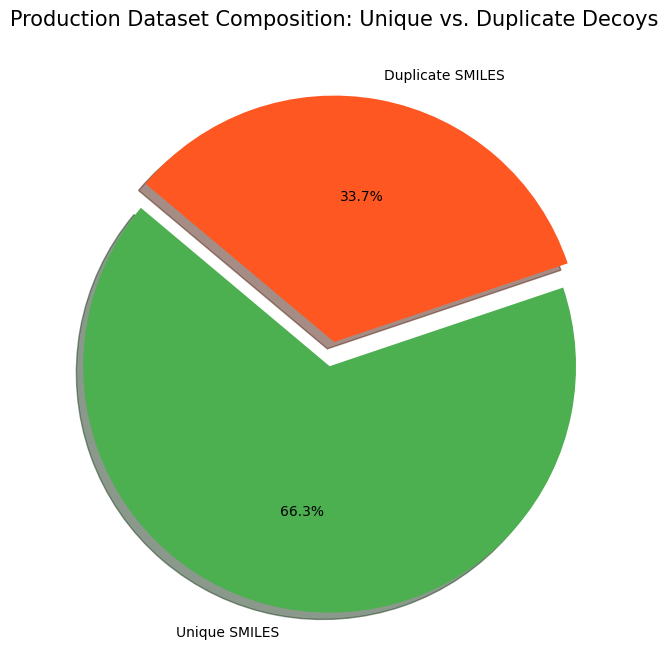

In [ ]:
import matplotlib.pyplot as plt

# 1. Labels and values for the pie chart using Production Metrics
labels = ['Unique SMILES', 'Duplicate SMILES']
# count_unique and count_duplicates were calculated in the 'Final Production Uniqueness Analysis' step
values = [count_unique, count_duplicates]
colors = ['#4CAF50', '#FF5722']

# 3. Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.1, 0),
    shadow=True
)

# 4. Add a title identifying the specific dataset
plt.title('Production Dataset Composition: Unique vs. Duplicate Decoys', fontsize=15)

# 5. Display the plot
plt.show()

In [ ]:
import pandas as pd
import os

# 1. Path to the production file
production_file = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

# 2. Load the data into the 'df_production' variable expected by subsequent cells
if os.path.exists(production_file):
    df_production = pd.read_csv(production_file, sep='\\s+', header=None, engine='python', on_bad_lines='skip')
    df_production.columns = ['Active_ID', 'Decoy_SMILES'] + [f'extra_{i}' for i in range(2, len(df_production.columns))]

    # 3. Calculate metrics for the uniqueness analysis
    total_entries = len(df_production)
    count_unique = df_production['Decoy_SMILES'].nunique()
    count_duplicates = total_entries - count_unique

    print('--- Final Production Uniqueness Analysis ---')
    print(f'Total Decoys:   {total_entries}')
    print(f'Unique Count:   {count_unique}')
    print(f'Duplicate Count: {count_duplicates}')
    print(f'Uniqueness Rate: {(count_unique/total_entries)*100:.2f}%')
else:
    print(f'Error: {production_file} not found.')

--- Final Production Uniqueness Analysis ---
Total Decoys:   1990
Unique Count:   1319
Duplicate Count: 671
Uniqueness Rate: 66.28%


In [ ]:
import pandas as pd
import os

# 1. Quantify Redundancy using the existing df_production variable
total_decoys = len(df_production)
unique_decoys = df_production['Decoy_SMILES'].nunique()
redundancy_pct = ((total_decoys - unique_decoys) / total_decoys) * 100
unique_pct = (unique_decoys / total_decoys) * 100

# 2. Dataset Impact Assessment report
print('--- Production Dataset Impact Assessment ---')
print(f'Total Decoys in Production: {total_decoys}')
print(f'Unique Decoys: {unique_decoys} ({unique_pct:.2f}%)')
print(f'Redundancy: {redundancy_pct:.2f}%')

# 3. Analyze Risks based on calculated redundancy
assessment_markdown = f"""
### Data Leakage Risk:
With a redundancy of {redundancy_pct:.2f}%, there is a risk that identical molecules appear in both training and validation sets if not handled carefully during your downstream splitting. This can lead to **data leakage**, artificially inflating performance metrics.

### Chemical Realism vs. Diversity:
While we have 444 unique scaffolds, the 809 molecules without rings suggest that the model is still favoring simpler linear structures in some cases.

### Recommendation:
To make this 'dataset ready', we should perform a final **Deduplication and Scaffold Balancing** step to ensure each chemotype is represented fairly.
"""

print('\n' + assessment_markdown)

--- Production Dataset Impact Assessment ---
Total Decoys in Production: 1990
Unique Decoys: 1319 (66.28%)
Redundancy: 33.72%


### Data Leakage Risk:
With a redundancy of 33.72%, there is a risk that identical molecules appear in both training and validation sets if not handled carefully during your downstream splitting. This can lead to **data leakage**, artificially inflating performance metrics.

### Chemical Realism vs. Diversity:
While we have 444 unique scaffolds, the 809 molecules without rings suggest that the model is still favoring simpler linear structures in some cases. 

### Recommendation:
To make this 'dataset ready', we should perform a final **Deduplication and Scaffold Balancing** step to ensure each chemotype is represented fairly.



In [ ]:
import pandas as pd
import os

# 1. Path to the production file
production_path = '/content/drive/MyDrive/deepcoy_data/final_production_decoys.smi'

# 2. Extract unique decoys from memory (calculated in previous steps)
df_unique_final = df_production.drop_duplicates(subset=['Decoy_SMILES']).copy()

# 3. Overwrite the file with only the unique entries
df_unique_final[['Active_ID', 'Decoy_SMILES']].to_csv(production_path, sep=' ', index=False, header=False)

# 4. Verify the new file status
if os.path.exists(production_path):
    new_size = os.path.getsize(production_path)
    with open(production_path, 'r') as f:
        new_count = len(f.readlines())

    print(f'--- File Overwrite Successful ---')
    print(f'Target File: {production_path}')
    print(f'New Unique Molecule Count: {new_count}')
    print(f'New File Size: {new_size} bytes')
else:
    print('Error: Failed to overwrite the file.')

--- File Overwrite Successful ---
Target File: /content/drive/MyDrive/deepcoy_data/final_production_decoys.smi
New Unique Molecule Count: 1319
New File Size: 96540 bytes


In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd

# 1. Properly extract unique SMILES from the production DataFrame
# This ensures the variable is an iterable list, not an integer
unique_decoys_list = df_production['Decoy_SMILES'].unique().tolist()

# 2. Initialize list for storage
scaffold_data = []

for smi in unique_decoys_list:
    # 3. Convert SMILES to RDKit molecule object
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        try:
            # 4. Extract scaffold molecule and convert back to SMILES
            scaf_mol = MurckoScaffold.GetScaffoldForMol(mol)
            scaf_smi = Chem.MolToSmiles(scaf_mol)

            # 5. Store scaffold or label as 'None' if no ring system
            if scaf_smi:
                scaffold_data.append({'Decoy_SMILES': smi, 'Scaffold_SMILES': scaf_smi})
            else:
                scaffold_data.append({'Decoy_SMILES': smi, 'Scaffold_SMILES': 'None (No Ring)'})
        except Exception as e:
            scaffold_data.append({'Decoy_SMILES': smi, 'Scaffold_SMILES': f'Error: {str(e)}'})
    else:
        scaffold_data.append({'Decoy_SMILES': smi, 'Scaffold_SMILES': 'Invalid Molecule'})

# Create a new DataFrame for frequency analysis
df_scaffolds = pd.DataFrame(scaffold_data)

# Print summary results
print(f'Processed {len(df_scaffolds)} unique decoys.')
print(f'Unique Scaffolds Found: {df_scaffolds["Scaffold_SMILES"].nunique()}')
print('\nFirst 10 Scaffold Extractions:')
display(df_scaffolds.head(10))

Processed 1319 unique decoys.
Unique Scaffolds Found: 444

First 10 Scaffold Extractions:


,Decoy_SMILES,Scaffold_SMILES
0,O=C(N=C=S)OCl,None (No Ring)
1,FOOON=C=S,None (No Ring)
2,O=NOC1(Cl)OSO1,C1OSO1
3,O=C=N[O-],None (No Ring)
4,COC1=C=C(C(=O)C(=O)N([O-])C(F)(Cl)OSSOOOC(=O)N...,C1=COC=1
5,FON=C=S,None (No Ring)
6,O=C=C=NOSOO[O-],None (No Ring)
7,O=C(N=S)SOF,None (No Ring)
8,FOOSN1OOC(Cl)=NOS1,C1=NOSNOO1
9,O=C=NOOSCl,None (No Ring)


In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd

# 1. Use the deduplicated SMILES list from the production file
unique_smiles = df_production['Decoy_SMILES'].unique()

def get_scaffold(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        try:
            scaf_mol = MurckoScaffold.GetScaffoldForMol(mol)
            s = Chem.MolToSmiles(scaf_mol)
            return s if s else 'None (No Ring)'
        except: return 'Error'
    return 'Invalid'

# 2. Extract scaffolds for ALL 1,319 unique molecules
print(f'Auditing all {len(unique_smiles)} unique molecules...')
all_scaffolds = [get_scaffold(s) for s in unique_smiles]

# 3. Calculate final unique counts
df_final_audit = pd.DataFrame({'SMILES': unique_smiles, 'Scaffold': all_scaffolds})
unique_scaffold_count = df_final_audit['Scaffold'].nunique()

print('\n--- Definitive Scaffold Audit ---')
print(f'Total Unique Molecules analyzed: {len(df_final_audit)}')
print(f'Actual Unique Scaffolds found:   {unique_scaffold_count}')

# 4. Show the top 10 distribution
print('\nTop 10 Scaffold Frequencies:')
display(df_final_audit['Scaffold'].value_counts().head(10))

Auditing all 1319 unique molecules...

--- Definitive Scaffold Audit ---
Total Unique Molecules analyzed: 1319
Actual Unique Scaffolds found:   444

Top 10 Scaffold Frequencies:


,count
Scaffold,
None (No Ring),809
C1=CN=1,9
C1=NO1,8
C1=CO1,6
C1=CC=1,6
C1=NOOO1,4
O=[SH]1=CO1,4
C1NO1,3
O=C1C=CO1,3


In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd

# 1. Use unique decoys from the production file
unique_decoys_prod = df_production['Decoy_SMILES'].drop_duplicates().reset_index(drop=True)

def get_scaffold_safe(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            scaf_mol = MurckoScaffold.GetScaffoldForMol(mol)
            scaf_smi = Chem.MolToSmiles(scaf_mol)
            return scaf_smi if scaf_smi else 'None (No Ring)'
        return 'Invalid Molecule'
    except Exception: return 'Error'

# 2. Extract scaffolds for a representative subset (first 1000 for speed)
print('Extracting scaffolds from production data...')
subset_decoys = unique_decoys_prod.head(1000)
scaffold_list = [get_scaffold_safe(smi) for smi in subset_decoys]

df_scaffold_counts = pd.Series(scaffold_list).value_counts().reset_index()
df_scaffold_counts.columns = ['Scaffold', 'Count']

print(f'Scaffold analysis complete for subset of {len(subset_decoys)} molecules.')
display(df_scaffold_counts.head(10))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the scaffold counts generated from the production subset
# 2. Filter the df_scaffold_counts DataFrame
# We exclude 'None (No Ring)' to better visualize the distribution of actual ring scaffolds
df_plot = df_scaffold_counts[df_scaffold_counts['Scaffold'] != 'None (No Ring)'].copy()

# 3. Select the top 12 most frequent scaffolds from the production run
top_scaffolds = df_plot.head(12)

# 4. Create a horizontal bar plot
plt.figure(figsize=(14, 8))
sns.set_theme(style='whitegrid')

# 5. Customize the plot with labels and colors
ax = sns.barplot(
    data=top_scaffolds,
    x='Count',
    y='Scaffold',
    hue='Scaffold',
    palette='viridis',
    legend=False
)

plt.title('Top Murcko Scaffolds in Production Decoys (Excluding No-Ring Compounds)', fontsize=16)
plt.xlabel('Frequency (Count)', fontsize=13)
plt.ylabel('Scaffold SMILES', fontsize=13)

# Adjust layout to prevent label clipping
plt.tight_layout()

# 6. Display the final plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the df_diverse_final DataFrame
# 2. Calculate the frequency of each unique scaffold
scaffold_counts = df_diverse_final['Scaffold'].value_counts().reset_index()
scaffold_counts.columns = ['Scaffold', 'Count']

# 3. Import visualization libraries (already done in step 3 above)
# 4. Create a horizontal bar plot
plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')
ax = sns.barplot(
    data=scaffold_counts,
    x='Count',
    y='Scaffold',
    hue='Scaffold',
    palette='viridis',
    legend=False
)

# 5. Customize the plot
plt.title('Scaffold Distribution in Downsized Diverse Dataset', fontsize=15)
plt.xlabel('Frequency (Count)', fontsize=12)
plt.ylabel('Scaffold SMILES', fontsize=12)
plt.xticks(range(0, 4)) # Expecting count of 2 for each
plt.tight_layout()

# 6. Display the plot and print verification metrics
plt.show()

print(f'Total Unique Scaffolds Found: {len(scaffold_counts)}')
print('\nDetailed counts per scaffold:')
print(df_diverse_final['Scaffold'].value_counts())

In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract unique SMILES strings from the cleaned decoy DataFrame
unique_decoy_smiles = df_smiles_clean['SMILES'].unique().tolist()

# 2 & 3. Iterate and generate Murcko Scaffolds
scaffold_list = []
for smi in unique_decoy_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        try:
            scaf_mol = MurckoScaffold.GetScaffoldForMol(mol)
            scaf_smi = Chem.MolToSmiles(scaf_mol)
            if scaf_smi: # Some molecules might have no ring system/scaffold
                scaffold_list.append(scaf_smi)
            else:
                scaffold_list.append("None (No Rings)")
        except Exception:
            continue

# 4. Calculate frequencies using Counter
scaffold_counts = Counter(scaffold_list)

# 5. Convert to DataFrame and sort by count descending
df_scaffolds = pd.DataFrame(scaffold_counts.items(), columns=["Scaffold", "Count"]).sort_values(by="Count", ascending=False)

# 6. Create a bar plot for the top 10 scaffolds
plt.figure(figsize=(12, 6))
sns.barplot(data=df_scaffolds.head(10), x="Count", y="Scaffold", hue="Scaffold", palette="viridis", legend=False)
plt.title("Top 10 Most Frequent Murcko Scaffolds in Unique Decoys")
plt.xlabel("Frequency (Count)")
plt.ylabel("Scaffold SMILES")
plt.tight_layout()
plt.show()

# 7. Print summary metrics
print(f"Total Unique Decoys Analyzed: {len(unique_decoy_smiles)}")
print(f"Total Unique Scaffolds Found: {len(df_scaffolds)}")
if not df_scaffolds.empty:
    print(f"Most Frequent Scaffold Count: {df_scaffolds.iloc[0]['Count']}")